## Criação da esteira para Normalização das fotos
- Bloco utilizado para processar todas as imagens de treino e "formatar" para um formato padrão para podermos usar-las.

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Definindo as regras da nossa "esteira"
# rescale=1./255 faz a normalização (divide todos os pixels por 255)
gerador_de_dados = ImageDataGenerator(rescale=1./255)

# Caminho para a sua pasta de treino
caminho_treino = 'chest_xray/train'

# 2. Ligando a esteira e conectando na pasta
# O flow_from_directory lê a pasta, corta as imagens no target_size,
# agrupa em lotes (batch_size) e entende que temos 2 categorias (class_mode='binary')
dados_treino = gerador_de_dados.flow_from_directory(
    caminho_treino,
    target_size=(224, 224), # Forçando todas as imagens a terem altura 224 e largura 224
    batch_size=32,          # Ele vai processar 32 imagens por vez
    class_mode='binary'     # 0 para Normal, 1 para Pneumonia
)

# 3. Pegando o primeiro lote (batch) que saiu da esteira para inspecionar
imagens, rotulos = next(dados_treino)

print("\n--- Analisando o lote que saiu da esteira ---")
print("Formato do lote de imagens:", imagens.shape)
print("Formato do lote de rótulos (labels):", rotulos.shape)
print("Exemplo de rótulos:", rotulos[:5])
print("Maior valor de pixel agora:", imagens.max())

Found 5216 images belonging to 2 classes.

--- Analisando o lote que saiu da esteira ---
Formato do lote de imagens: (32, 224, 224, 3)
Formato do lote de rótulos (labels): (32,)
Exemplo de rótulos: [1. 1. 0. 0. 1.]
Maior valor de pixel agora: 1.0


## Proteção contra Overfitting: criação do Data Augmentation
- utilizado para aplicar uma leve "distorção" para meio que atrapalhar o processamento das imagens fornecidas pela esteira anterior, de forma com que evite que o computador não consiga "decorar" padrões, obrigando ele a entender realmente qual a lógica das imagens.


Conectando aos dados de Treinamento:
Found 5216 images belonging to 2 classes.

Conectando aos dados de Validação:
Found 16 images belonging to 2 classes.

Conectando aos dados de Teste:
Found 624 images belonging to 2 classes.


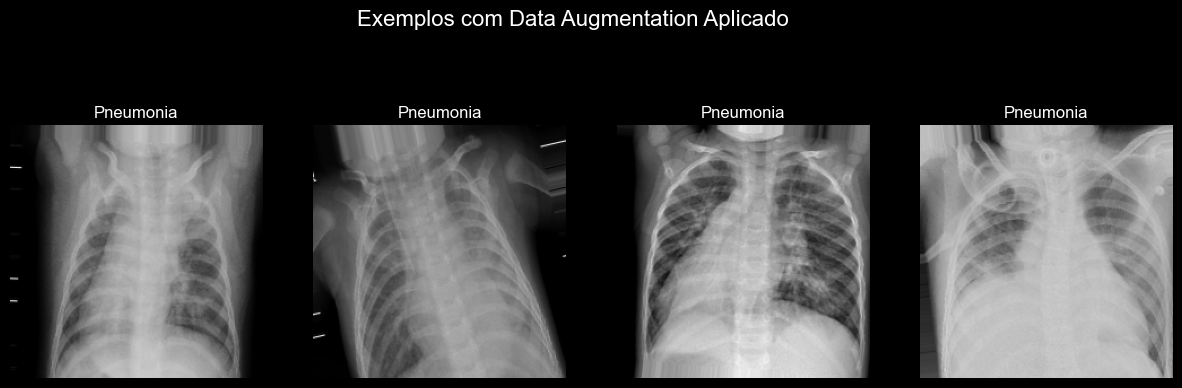

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Esteira de TREINO com Data Augmentation
# Adicionamos "ruídos" saudáveis para evitar o overfitting
gerador_treino = ImageDataGenerator(
    rescale=1./255,          # Normalização (obrigatória)
    rotation_range=15,       # Rotaciona aleatoriamente a imagem em até 15 graus
    width_shift_range=0.1,   # Desloca a imagem para a esquerda/direita em até 10%
    height_shift_range=0.1,  # Desloca a imagem para cima/baixo em até 10%
    zoom_range=0.1,          # Aplica um zoom in/out aleatório de até 10%
    horizontal_flip=True,    # Pode espelhar a imagem horizontalmente
    fill_mode='nearest'      # Preenche pixels vazios caso a imagem saia do quadro
)

# 2. Esteiras de VALIDAÇÃO e TESTE sem Augmentation
# Apenas normalizamos, pois queremos avaliar imagens reais, não imagens contorcidas
gerador_teste = ImageDataGenerator(rescale=1./255)

# Definindo caminhos
caminho_treino = 'chest_xray/train'
caminho_val = 'chest_xray/val'
caminho_teste = 'chest_xray/test'

# 3. Conectando as esteiras aos diretórios
print("\nConectando aos dados de Treinamento:")
dados_treino = gerador_treino.flow_from_directory(
    caminho_treino,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print("\nConectando aos dados de Validação:")
dados_val = gerador_teste.flow_from_directory(
    caminho_val,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print("\nConectando aos dados de Teste:")
dados_teste = gerador_teste.flow_from_directory(
    caminho_teste,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Não embaralhamos os testes para não perder a ordem na hora de avaliar
)

# --- BÔNUS VISUAL: Mostrando o Augmentation na Prática ---
# Pegamos apenas as imagens do primeiro lote (batch) gerado
imagens, rotulos = next(dados_treino)

# Vamos plotar as 4 primeiras imagens desse lote para ver como elas ficaram
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i in range(4):
    axes[i].imshow(imagens[i]) # Exibe a imagem processada

    # O rótulo é um número float (0.0 ou 1.0). Convertendo para o nome:
    titulo = "Pneumonia" if rotulos[i] == 1.0 else "Normal"
    axes[i].set_title(titulo)
    axes[i].axis('off')

plt.suptitle("Exemplos com Data Augmentation Aplicado", fontsize=16)
plt.show()

## Entrando com técnica do Transfer Learning
- Importando a rede neural MobileNetV2 para analisar as imagens e acelerar nosso processo.
- Importamos o "cerébro", depois "congelamos" ele para somente responder o que precisamos, e só após montamos o modelo sequencial que vamos utilizar.

In [12]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# 1. Importando o "cérebro" pré-treinado (MobileNetV2)
print("A descarregar o modelo base MobileNetV2...")
modelo_base = MobileNetV2(
    input_shape=(224, 224, 3), # O tamanho que definimos no nosso pipeline
    include_top=False,         # MUITO IMPORTANTE: Isso "arranca" a camada final original
    weights='imagenet'         # Carrega o conhecimento que ela aprendeu no Google
)

# 2. Congelando o cérebro
# Dizemos ao Python: "Não mexa no que ela já aprendeu! Apenas use."
modelo_base.trainable = False

# 3. Construindo o NOSSO modelo (juntando as peças)
modelo = Sequential([
    modelo_base,                  # A base inteligente do Google
    GlobalAveragePooling2D(),     # Resume as informações visuais numa linguagem matemática mais simples
    Dense(128, activation='relu'),# Uma nova camada para processar os dados do Raio-X
    Dropout(0.5),                 # Desliga 50% dos "neurónios" aleatoriamente para evitar Overfitting
    Dense(1, activation='sigmoid')# A nossa saída final! 1 neurónio que cospe 0 (Normal) ou 1 (Pneumonia)
])

# 4. Exibindo o resumo do que acabamos de construir
print("\n--- Resumo da nossa Rede Neural ---")
modelo.summary()

A descarregar o modelo base MobileNetV2...

--- Resumo da nossa Rede Neural ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Compilando e Treinando

In [13]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 1. Compilando o modelo (Definindo como ele aprende e como ele é avaliado)
modelo.compile(
    optimizer=Adam(learning_rate=0.0001), # Passos pequenos (0.0001) para não esquecer o que o Google já ensinou
    loss='binary_crossentropy',           # A fórmula de erro padrão para problemas de SIM ou NÃO
    metrics=['accuracy']                  # Queremos que ele imprima a taxa de acerto (Acurácia)
)

# 2. O Freio de Segurança (Early Stopping)
# Se o modelo parar de melhorar nas imagens de validação por 3 rodadas seguidas (patience=3),
# ele interrompe o treinamento para o seu computador não ficar processando à toa.
freio_de_mao = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True # Garante que vamos salvar a melhor versão, e não a última
)

# 3. O Treinamento (A hora da verdade!)
print("Iniciando o treinamento. Vá pegar um café, isso pode demorar alguns minutos...")

historico = modelo.fit(
    dados_treino,             # Nossa esteira de imagens com "bagunça"
    epochs=10,                # Quantas vezes ele vai estudar o dataset inteiro (10 rodadas/épocas)
    validation_data=dados_val,# Nossa esteira de validação (a prova "limpa" ao final de cada rodada)
    callbacks=[freio_de_mao]  # Acionando o freio
)

print("\nTreinamento inicial finalizado com sucesso!")


Iniciando o treinamento. Vá pegar um café, isso pode demorar alguns minutos...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 529ms/step - accuracy: 0.8436 - loss: 0.3493 - val_accuracy: 0.8750 - val_loss: 0.3730
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 498ms/step - accuracy: 0.9220 - loss: 0.1961 - val_accuracy: 0.8750 - val_loss: 0.3603
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 492ms/step - accuracy: 0.9337 - loss: 0.1653 - val_accuracy: 0.8125 - val_loss: 0.3122
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 493ms/step - accuracy: 0.9427 - loss: 0.1484 - val_accuracy: 0.8125 - val_loss: 0.3115
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 501ms/step - accuracy: 0.9434 - loss: 0.1434 - val_accuracy: 0.8125 - val_loss: 0.2969
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 504ms/step - accuracy: 0.9498 - loss: 0.1284 - val_accuracy: 0.8125 - val_loss: 0.3567
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 502ms/step - accuracy: 0.9561 - loss: 0.1172 - val_accuracy: 0.8125 - val_loss: 0.3143
Epoc

## Avaliação Final

Preparando os dados de teste para a avaliação final...
O modelo está analisando os raios-x de teste...
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 362ms/step

RELATÓRIO DE DESEMPENHO MÉDICO
              precision    recall  f1-score   support

      Normal       0.92      0.76      0.83       234
   Pneumonia       0.87      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624


Gerando a Matriz de Confusão visual...


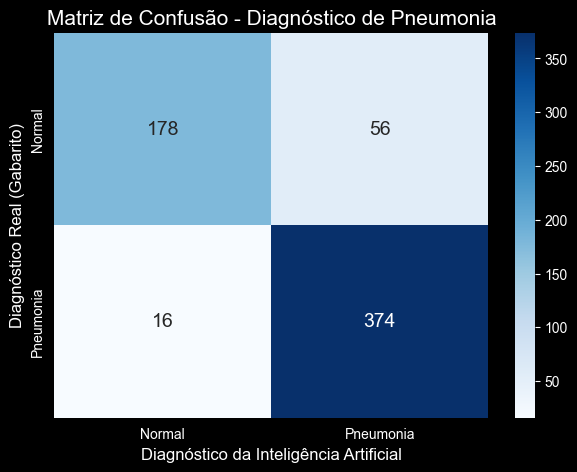

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Preparando os dados de teste para a avaliação final...")

# 1. Resetamos a esteira de testes para garantir que ela comece da primeira imagem
dados_teste.reset()

# 2. Pedimos para a Inteligência Artificial dar o diagnóstico de TODAS as imagens de teste
print("O modelo está analisando os raios-x de teste...")
previsoes_probabilidade = modelo.predict(dados_teste)

# Como o modelo cospe probabilidades (ex: 0.85), transformamos isso em 0 ou 1.
# Se a certeza for maior que 50% (0.5), dizemos que é 1 (Pneumonia). Senão, 0 (Normal).
previsoes_finais = (previsoes_probabilidade > 0.5).astype(int)

# Pegamos o gabarito real (o que os médicos humanos disseram que era)
gabarito_real = dados_teste.classes

# 3. Gerando o Relatório Médico (Classification Report)
nomes_das_classes = ['Normal', 'Pneumonia']
print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO MÉDICO")
print("="*50)
print(classification_report(gabarito_real, previsoes_finais, target_names=nomes_das_classes))

# 4. Desenhando a Matriz de Confusão
print("\nGerando a Matriz de Confusão visual...")

# Calculando a matriz
matriz = confusion_matrix(gabarito_real, previsoes_finais)

# Estilizando o gráfico
plt.figure(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=nomes_das_classes,
            yticklabels=nomes_das_classes,
            annot_kws={"size": 14}) # Aumenta o tamanho da fonte dos números

plt.title("Matriz de Confusão - Diagnóstico de Pneumonia", fontsize=15)
plt.ylabel("Diagnóstico Real (Gabarito)", fontsize=12)
plt.xlabel("Diagnóstico da Inteligência Artificial", fontsize=12)
plt.show()

## Fine-Tuning

In [15]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Iniciando o Fine-Tuning: Descongelando as camadas finais do cérebro base...")

# 1. Descongelamos o cérebro da MobileNetV2
modelo_base.trainable = True

# 2. Re-congelamos quase tudo, deixando apenas as últimas 20 camadas livres
# Assim evitamos destruir o conhecimento básico que ela já tem de formas e bordas
for camada in modelo_base.layers[:-20]:
    camada.trainable = False

# 3. Precisamos recompilar o modelo porque mudamos as regras do jogo
# AVISO CRUCIAL: A taxa de aprendizado (learning_rate) agora é MICROSCÓPICA (0.00001)
# Se der passos largos agora, o modelo desaprende o que já sabe!
modelo.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- Resumo Pós Descongelamento ---")
# Veja que os "Trainable params" aumentaram!
modelo.summary()

# 4. Novo freio de mão e novo treinamento
freio_fino = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nIniciando o refinamento mestre. Pode demorar mais um pouquinho...")
historico_fino = modelo.fit(
    dados_treino,
    epochs=10,
    validation_data=dados_val,
    callbacks=[freio_fino]
)

print("\nRefinamento finalizado!")

# 5. Salvando o seu modelo para não perder (O arquivo final que você leva pro mundo real!)
modelo.save('meu_modelo_pneumonia_final.keras')
print("Modelo salvo como 'meu_modelo_pneumonia_final.keras'. Guarde este ficheiro com carinho!")

Iniciando o Fine-Tuning: Descongelando as camadas finais do cérebro base...

--- Resumo Pós Descongelamento ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,370,177 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)


Iniciando o refinamento mestre. Pode demorar mais um pouquinho...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 668ms/step - accuracy: 0.9273 - loss: 0.1871 - val_accuracy: 0.7500 - val_loss: 0.5149
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 562ms/step - accuracy: 0.9440 - loss: 0.1451 - val_accuracy: 0.6250 - val_loss: 0.8494
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 563ms/step - accuracy: 0.9500 - loss: 0.1270 - val_accuracy: 0.6250 - val_loss: 1.2336
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 575ms/step - accuracy: 0.9571 - loss: 0.1103 - val_accuracy: 0.5625 - val_loss: 1.4138

Refinamento finalizado!
Modelo salvo como 'meu_modelo_pneumonia_final.keras'. Guarde este ficheiro com carinho!


### Rodar novamente o bloco de avaliação

Preparando os dados de teste para a avaliação final...
O modelo está analisando os raios-x de teste...
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 418ms/step

RELATÓRIO DE DESEMPENHO MÉDICO
              precision    recall  f1-score   support

      Normal       0.97      0.59      0.73       234
   Pneumonia       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624


Gerando a Matriz de Confusão visual...


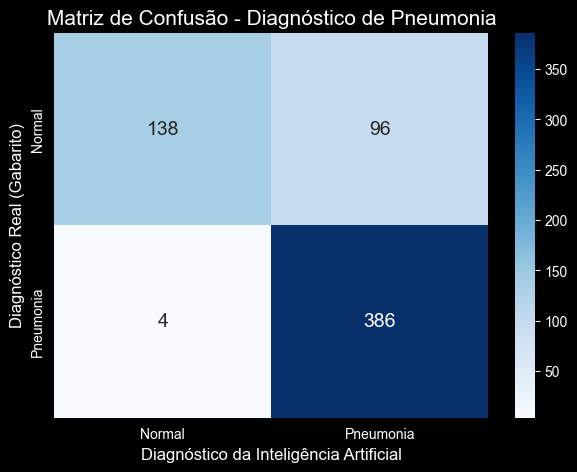

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Preparando os dados de teste para a avaliação final...")

# 1. Resetamos a esteira de testes para garantir que ela comece da primeira imagem
dados_teste.reset()

# 2. Pedimos para a Inteligência Artificial dar o diagnóstico de TODAS as imagens de teste
print("O modelo está analisando os raios-x de teste...")
previsoes_probabilidade = modelo.predict(dados_teste)

# Como o modelo cospe probabilidades (ex: 0.85), transformamos isso em 0 ou 1.
# Se a certeza for maior que 50% (0.5), dizemos que é 1 (Pneumonia). Senão, 0 (Normal).
previsoes_finais = (previsoes_probabilidade > 0.5).astype(int)

# Pegamos o gabarito real (o que os médicos humanos disseram que era)
gabarito_real = dados_teste.classes

# 3. Gerando o Relatório Médico (Classification Report)
nomes_das_classes = ['Normal', 'Pneumonia']
print("\n" + "="*50)
print("RELATÓRIO DE DESEMPENHO MÉDICO")
print("="*50)
print(classification_report(gabarito_real, previsoes_finais, target_names=nomes_das_classes))

# 4. Desenhando a Matriz de Confusão
print("\nGerando a Matriz de Confusão visual...")

# Calculando a matriz
matriz = confusion_matrix(gabarito_real, previsoes_finais)

# Estilizando o gráfico
plt.figure(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=nomes_das_classes,
            yticklabels=nomes_das_classes,
            annot_kws={"size": 14}) # Aumenta o tamanho da fonte dos números

plt.title("Matriz de Confusão - Diagnóstico de Pneumonia", fontsize=15)
plt.ylabel("Diagnóstico Real (Gabarito)", fontsize=12)
plt.xlabel("Diagnóstico da Inteligência Artificial", fontsize=12)
plt.show()